In [1]:
#Apply Raw
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
print("Features shape (raw version):", X.shape)

#Define Cluster Parameters
k_values = range(2, 9)  # clusters 2–8 for KMeans, GMM, Agglomerative, Spectral
n_init = 10  # random initialization for KMeans, GMM, Spectral
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch



Features shape (raw version): (2930, 172)


In [2]:
#K-Means on Raw Features

kmeans_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    sil, db, ch = compute_metrics(X, labels)
    kmeans_scores.append({"algorithm":"K-Means","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})
    

In [3]:
#GMM on Raw Features
gmm_scores = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    gmm.fit(X)
    labels = gmm.predict(X)
    sil, db, ch = compute_metrics(X, labels)
    gmm_scores.append({"algorithm":"GMM","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})


In [4]:
#Agglomerative Clustering
agg_scores = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg.fit(X)
    labels = agg.labels_
    sil, db, ch = compute_metrics(X, labels)
    agg_scores.append({"algorithm":"Agglomerative","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})



In [5]:
#Spectral Clustering
spectral_scores = []
for k in k_values:
    spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_init=n_init, random_state=42)
    spectral.fit(X)
    labels = spectral.labels_
    sil, db, ch = compute_metrics(X, labels)
    spectral_scores.append({"algorithm":"Spectral","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})


In [6]:
#DBSCAN
dbscan_scores = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X)
    labels = dbscan.labels_
    sil, db, ch = compute_metrics(X, labels)
    dbscan_scores.append({"algorithm":"DBSCAN","preprocessing":"raw","eps":eps,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})



In [7]:
import csv

results_raw = (kmeans_scores + gmm_scores + agg_scores + spectral_scores + dbscan_scores)

# Desired column order
keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]

with open('updated_data/ames_raw_scores.csv', 'w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_raw)

In [ ]:
# import pandas as pd
# import glob as glob

# # Get all CSV files in the directory
# csv_files = glob.glob('updated_data/*.csv')

# # Read the data from all CSV files into a single DataFrame
# df_all = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

# df_all
# #save
# df_all.to_csv("updated_data/ames_all_scores.csv", index=False)

# # df_all = pd.read_csv("updated_data/ames_all_scores.csv")
# # df_all

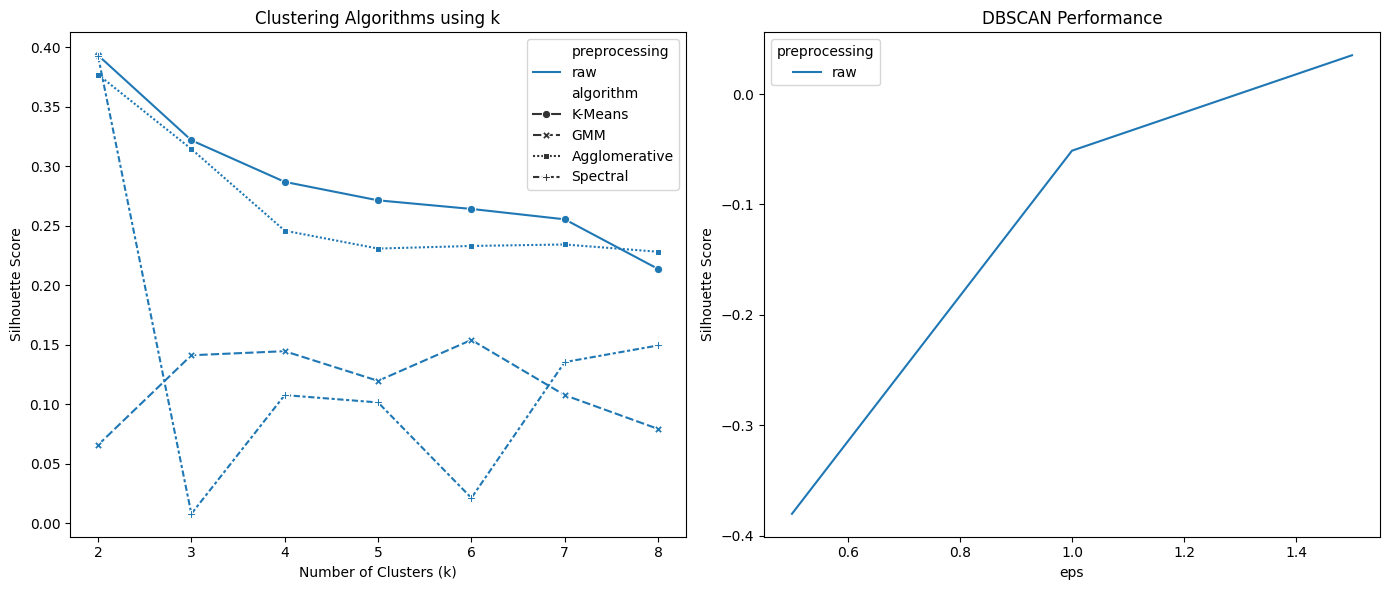

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="silhouette",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="silhouette",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

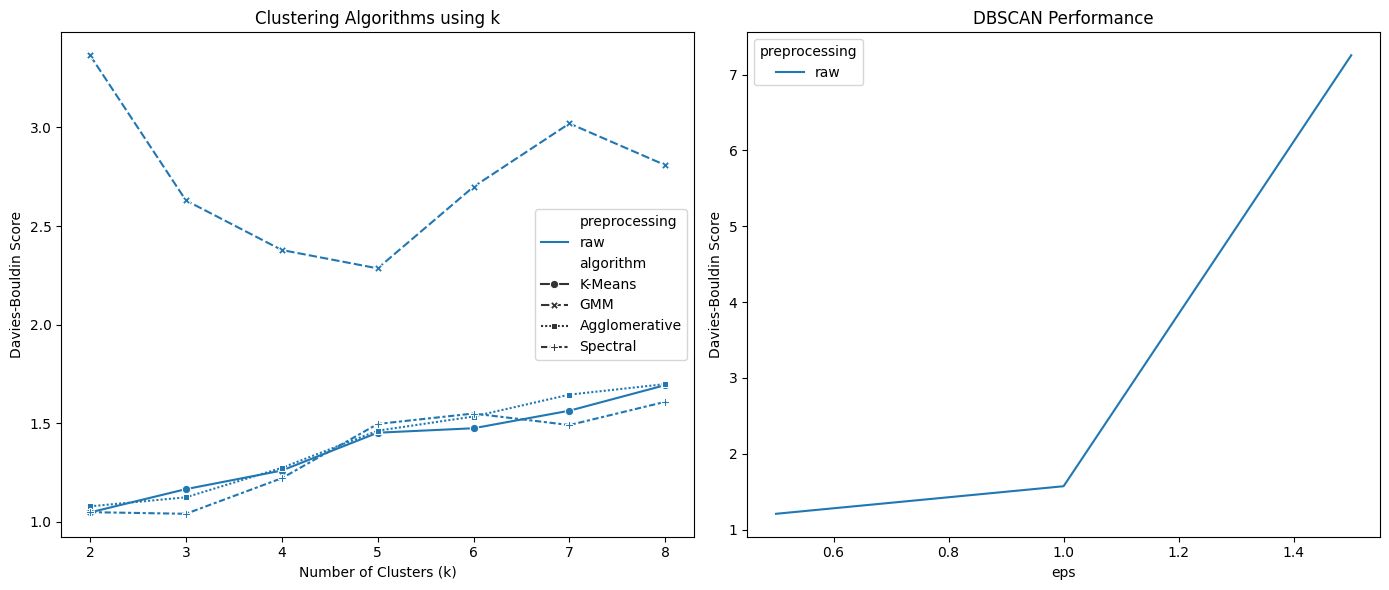

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="davies_bouldin",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Davies-Bouldin Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="davies_bouldin",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Davies-Bouldin Score")

plt.tight_layout()
plt.show()

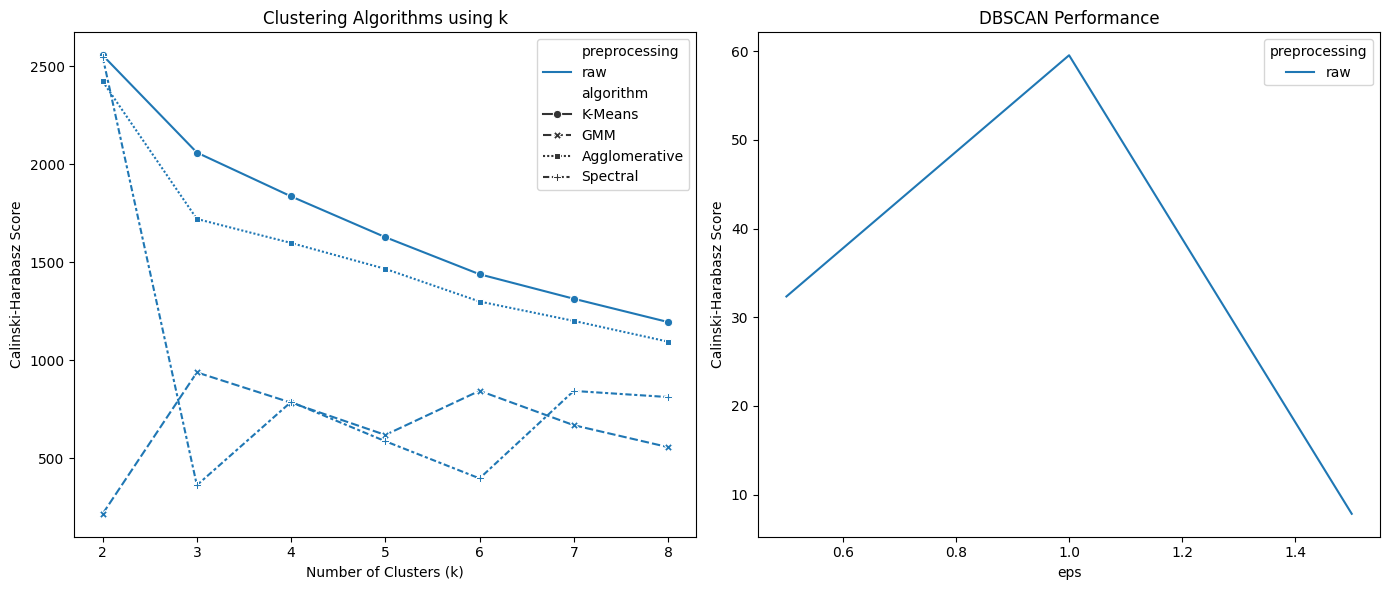

In [6]:
#compares preprocessing impact on clustering performance. Plot metrics vs number of clusters
import matplotlib.pyplot as plt
import seaborn as sns


df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="calinski_harabasz",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Calinski-Harabasz Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="calinski_harabasz",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Calinski-Harabasz Score")

plt.tight_layout()
plt.show()

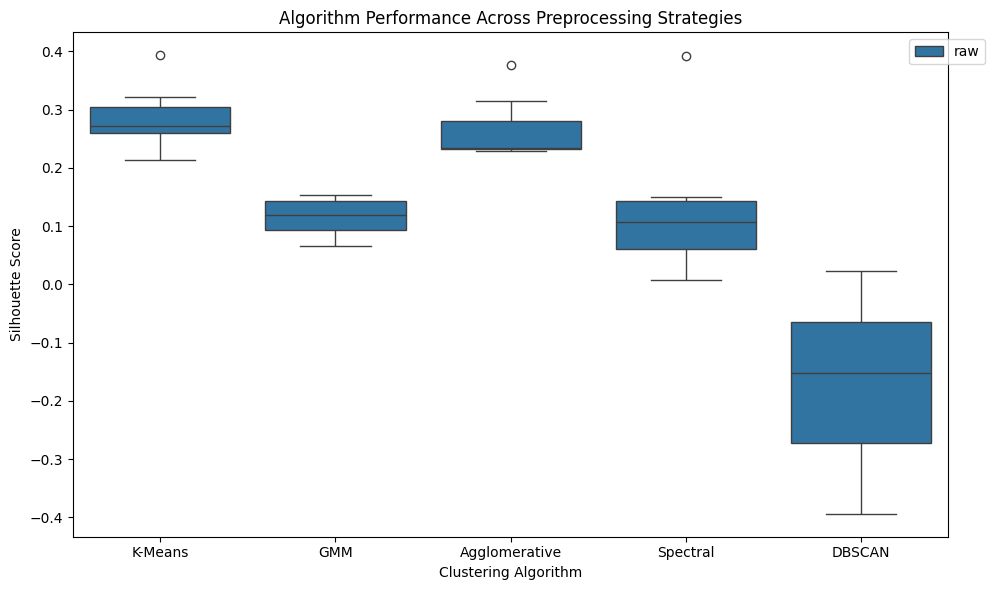

In [7]:
#compares algorithms across preprocessing methods
df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_raw,
    x="algorithm",
    y="silhouette",
    hue="preprocessing"
)

plt.title("Algorithm Performance Across Preprocessing Strategies")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

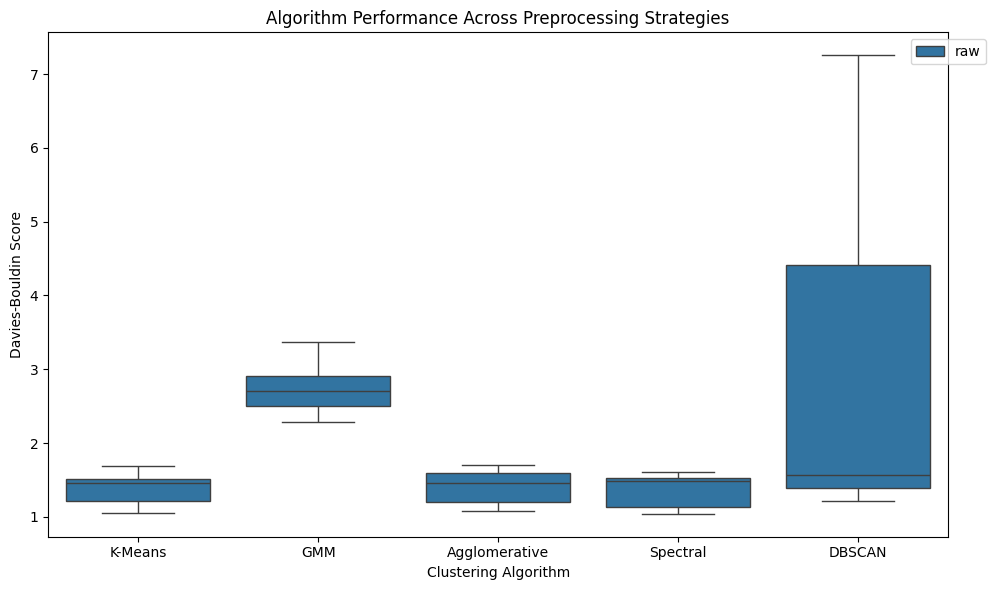

In [8]:

df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_raw,
    x="algorithm",
    y="davies_bouldin",
    hue="preprocessing"
)

plt.title("Algorithm Performance Across Preprocessing Strategies")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Davies-Bouldin Score")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

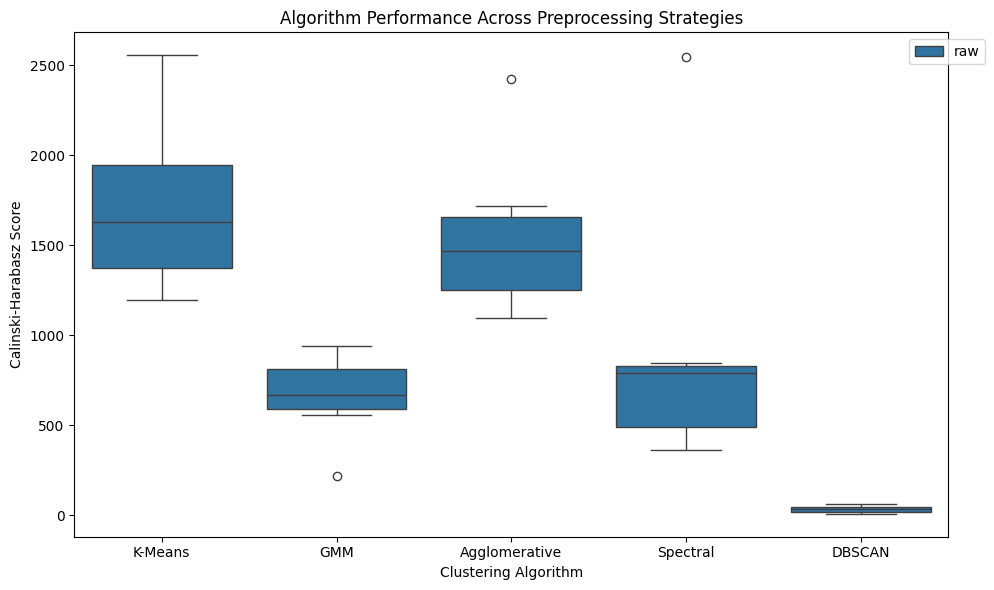

In [9]:

df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_raw,
    x="algorithm",
    y="calinski_harabasz",
    hue="preprocessing"
)

plt.title("Algorithm Performance Across Preprocessing Strategies")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Calinski-Harabasz Score")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

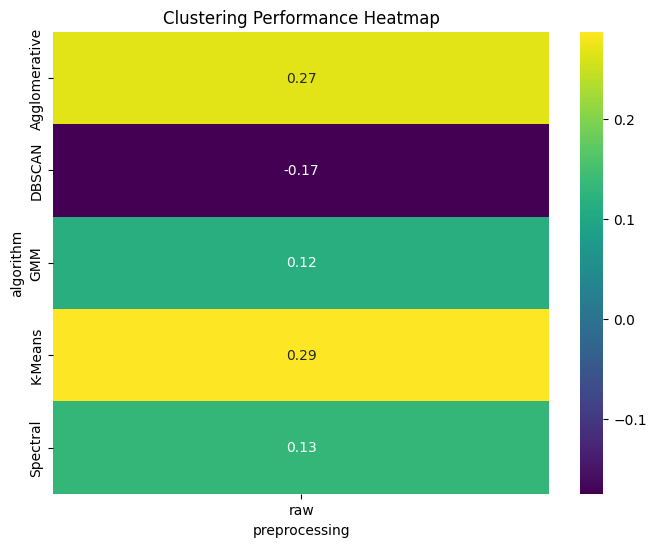

In [10]:
#Preprocessing Impact Heatmap

pivot = df_raw.pivot_table(
    values="silhouette",
    index="algorithm",
    columns="preprocessing"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="viridis"
)

plt.title("Clustering Performance Heatmap")
plt.show()

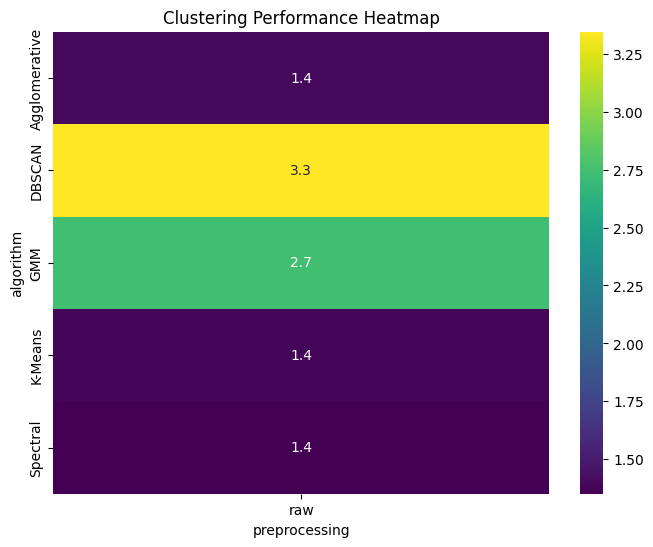

In [11]:
#Preprocessing Impact Heatmap

pivot = df_raw.pivot_table(
    values="davies_bouldin",
    index="algorithm",
    columns="preprocessing"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="viridis"
)

plt.title("Clustering Performance Heatmap")
plt.show()

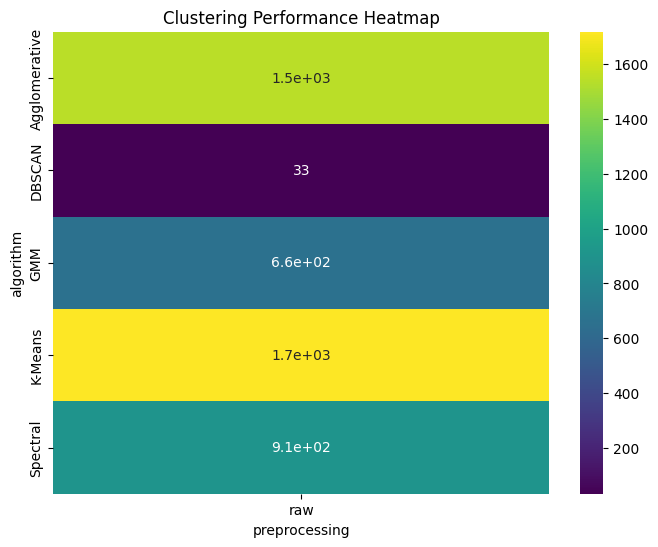

In [12]:
#Preprocessing Impact Heatmap

pivot = df_raw.pivot_table(
    values="calinski_harabasz",
    index="algorithm",
    columns="preprocessing"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="viridis"
)

plt.title("Clustering Performance Heatmap")
plt.show()

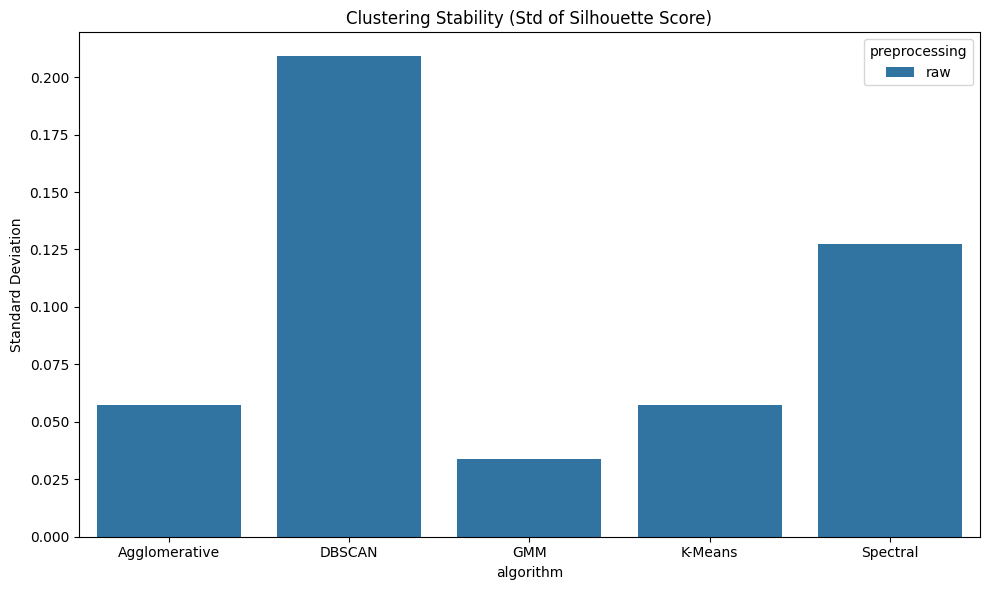

In [13]:
#Stability Plot 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


stability = df_raw.groupby(["algorithm", "preprocessing"])["silhouette"].std().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=stability,
    x="algorithm",
    y="silhouette",
    hue="preprocessing"
)

plt.title("Clustering Stability (Std of Silhouette Score)")
plt.ylabel("Standard Deviation")
plt.tight_layout()
plt.show()

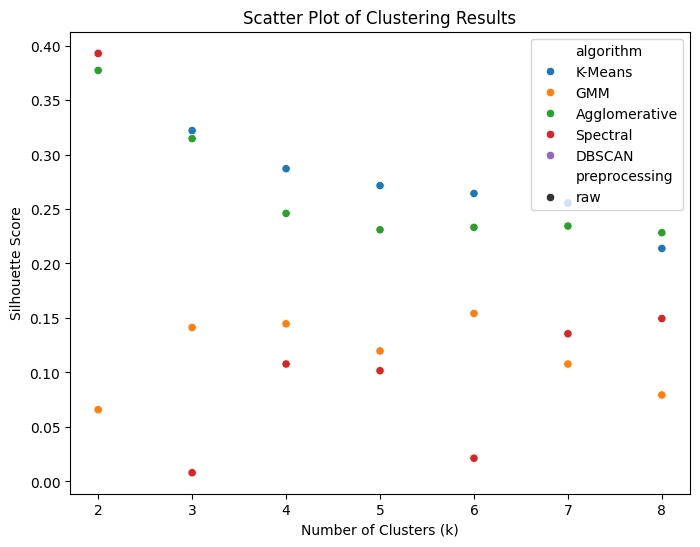

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("updated_data/ames_raw_scores.csv")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="k",              # or use your actual feature if you have 2D data
    y="silhouette",
    hue="algorithm",
    style="preprocessing"
)

plt.title("Scatter Plot of Clustering Results")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.show()